
# Project: Customer Churn Prediction using ANN
# Dataset: Churn_Modelling.csv
# Goal: Predict whether customer will exit or not




Steps:
1. Data Cleaning
2. Exploratory Data Analysis (EDA)
3. Encoding categorical features
4. Train-Test Split
5. Feature Scaling
6. Artificial Neural Network (ANN)
7. Early Stopping + Class Weight
8. Model Evaluation (Confusion Matrix, Report)
9. Accuracy & Loss Graph
10.Model Saving (Model+scaler)

Model: Sequential ANN (Dense + Dropout)


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('../dataset/raw/Churn_Modelling.csv',encoding='latin-1')


df_copy = df.copy(deep=True)
df_copy.head(3)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1


In [3]:
# total rows and columns
print('Total rows & columns',df_copy.shape)

Total rows & columns (10000, 14)


In [4]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [5]:
# now check for null values

df_copy.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [6]:
#check for duplicated values
df_copy.duplicated().sum()

np.int64(0)

In [7]:
# checking is there is any repeted customer behaviour 
df_copy['CustomerId'].duplicated().sum()

np.int64(0)

In [8]:
df_copy.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

In [9]:
# drop the first three columns
df_copy.drop(columns=['RowNumber', 'CustomerId', 'Surname'],inplace=True)

In [10]:
df_copy.columns

Index(['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance',
       'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
       'Exited'],
      dtype='object')

# EDA

<Axes: xlabel='Exited', ylabel='count'>

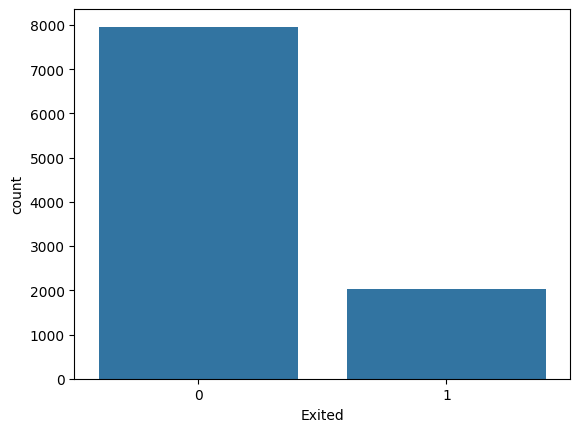

In [11]:
# how many customer churned vs stayed
import seaborn as sns
sns.countplot(x='Exited', data=df_copy)

### Observation:
The target variable is imbalanced, as the number of customers who stayed
is much higher than those who churned.

<Axes: xlabel='Exited', ylabel='Age'>

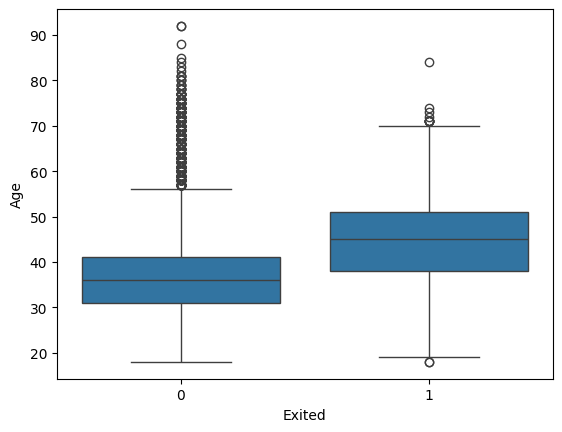

In [12]:
# which age people churn more
sns.boxplot(x='Exited',y='Age',data=df_copy)

### Observation:
Older people tend to churn more compared to younger people.

<Axes: xlabel='Exited', ylabel='Balance'>

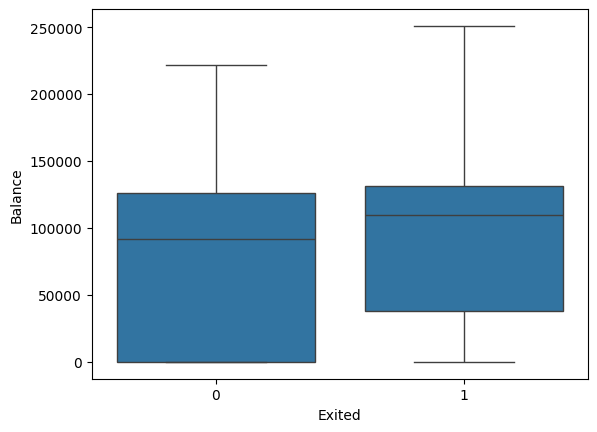

In [13]:
# Do customers with higher balance churn more
sns.boxplot(x='Exited',y='Balance',data=df_copy)

### Observation:
Customers with higher balance tend to churn more than customers with low or zero balance.

<Axes: xlabel='Exited', ylabel='CreditScore'>

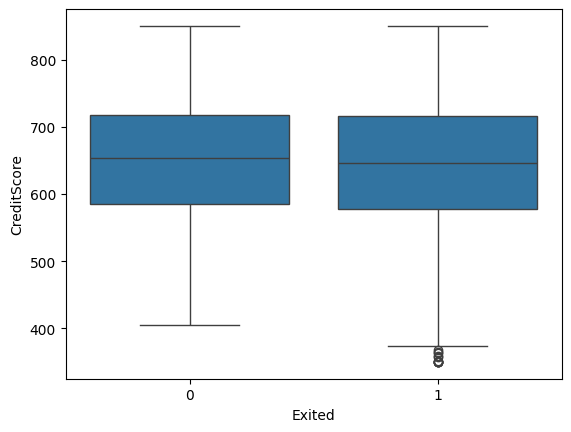

In [14]:
# creaditscore vs churn
sns.boxplot(x='Exited',y='CreditScore',data=df_copy)

### Observation:
Credit score distribution is similar for exited and non-exited customers, but there are some that has very low score and they leave

<Axes: xlabel='Exited', ylabel='Tenure'>

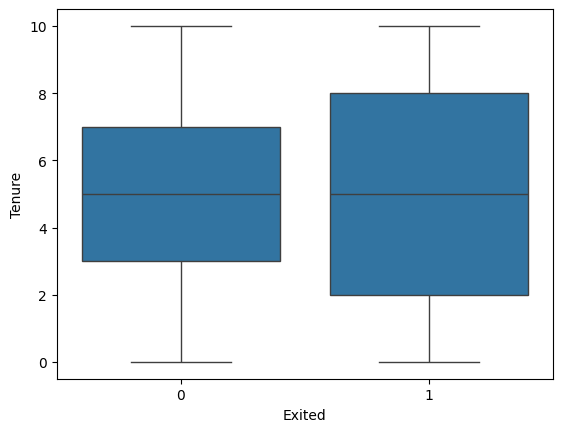

In [15]:
# Does tenure affect churn
sns.boxplot(x="Exited", y="Tenure", data=df_copy)

### Observation:
Tenure is similar for churned and non-churned customers,but about 25% of churned customers have tenure ≤ 2

<Axes: xlabel='Exited', ylabel='EstimatedSalary'>

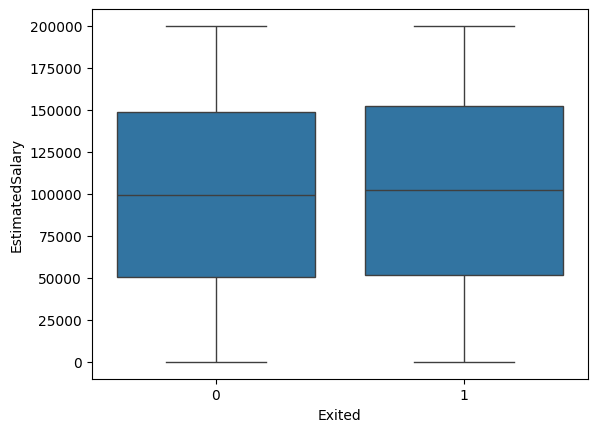

In [16]:
# salary vs churn
sns.boxplot(x='Exited',y='EstimatedSalary',data=df_copy)

### Observation:
churned and non-churned customers has same salary.

<Axes: xlabel='Geography', ylabel='count'>

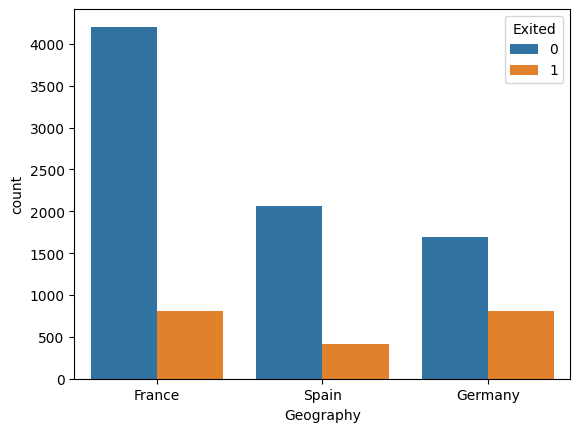

In [17]:
# Which Geography has highest churn
sns.countplot(x="Geography", hue="Exited", data=df_copy)

### Observation:
Germany : Lowest number of non-churn customers and Highest number of churn customers.

France : Highest number of customers and Less chern rate than Germany.

Spain : Higher number of non-churn customers than Germany and Lowest churn.

<Axes: xlabel='Gender', ylabel='count'>

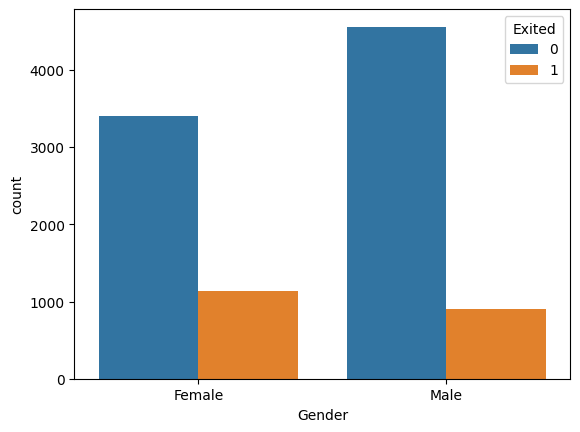

In [18]:
# Gender vs churn
sns.countplot(x='Gender',hue='Exited',data=df_copy)

### Observation:
Female customers have higher churn compared to male customers.

Even though the total number of male customers is higher.

<Axes: xlabel='NumOfProducts', ylabel='count'>

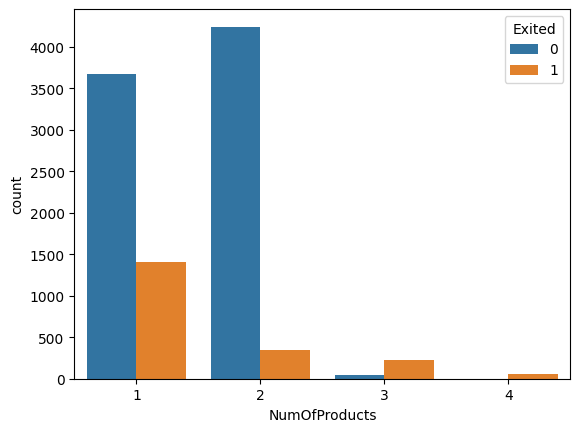

In [19]:
# Do customers with more products stay more
sns.countplot(x="NumOfProducts", hue="Exited", data=df_copy)

### Observation:
Churn is lowest for customers with 2 products
and higher for customers with 1 or more than 2 products.

<Axes: xlabel='IsActiveMember', ylabel='count'>

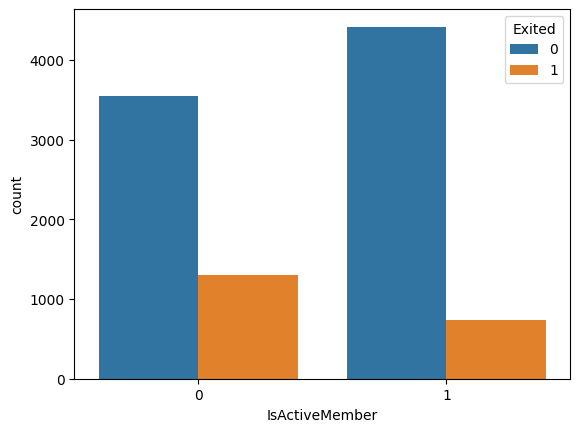

In [20]:
# Do isactive members churn more
sns.countplot(x="IsActiveMember", hue="Exited", data=df_copy)

### Observation:
Customers who are not active members show higher churn,

<Axes: xlabel='Geography', ylabel='IsActiveMember'>

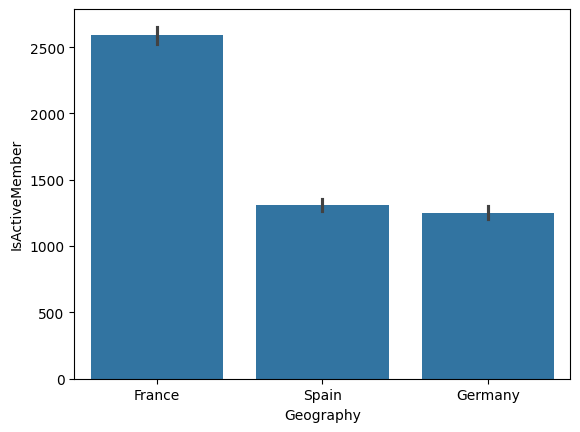

In [21]:
# Which Geography has most active members
sns.barplot(
    x="Geography",
    y="IsActiveMember",
    data=df_copy,
    estimator=sum
)

### Observation:
France has the highest number of active members,

while Spain and Germany have fewer active customers.

<Axes: >

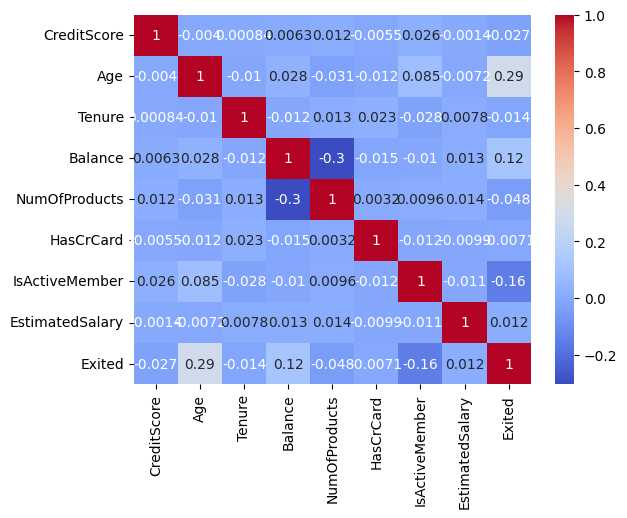

In [22]:
sns.heatmap(
    df_copy.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

### Observation:
Strongest features:
Age, IsActiveMember, Balance, Geography (from countplot), NumOfProducts (from countplot)

Weak features:
CreditScore, Salary, Tenure, HasCrCard

# Encoding

In [23]:
# Geography + Gender
df_copy = pd.get_dummies(df_copy,drop_first=True).astype(int)

In [24]:
df_copy.head(3)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0,1,1,1,101348,1,0,0,0
1,608,41,1,83807,1,0,1,112542,0,0,1,0
2,502,42,8,159660,3,1,0,113931,1,0,0,0


# Divide the columns into features and target 

In [25]:
X = df_copy.drop(columns=['Exited'])
y = df_copy['Exited']

In [26]:
X

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0,1,1,1,101348,0,0,0
1,608,41,1,83807,1,0,1,112542,0,1,0
2,502,42,8,159660,3,1,0,113931,0,0,0
3,699,39,1,0,2,0,0,93826,0,0,0
4,850,43,2,125510,1,1,1,79084,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0,2,1,0,96270,0,0,1
9996,516,35,10,57369,1,1,1,101699,0,0,1
9997,709,36,7,0,1,0,1,42085,0,0,0
9998,772,42,3,75075,2,1,0,92888,1,0,1


In [27]:
y

0       1
1       0
2       1
3       0
4       0
       ..
9995    0
9996    0
9997    1
9998    1
9999    0
Name: Exited, Length: 10000, dtype: int64

# now train_test_split

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

# Normalization

In [29]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train_sc = sc.fit_transform(X_train)
X_test_sc = sc.transform(X_test)

# ANN MODEL

In [30]:
from tensorflow.keras.models import Sequential #type:ignore
from tensorflow.keras.layers import Dense , Dropout#type:ignore

model = Sequential()

# Input + Hidden layer
model.add(Dense(16, activation='relu',input_dim=X_train_sc.shape[1]))
model.add(Dropout(0.2))

# Hidden layer
model.add(Dense(8,activation='relu'))
model.add(Dropout(0.2))

# Hidden layer 
model.add(Dense(4, activation='relu'))

# Output layer
model.add(Dense(1,activation='sigmoid'))

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

c:\Users\ASUS\OneDrive\Desktop\py\venvcls\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 369 (1.44 KB)

 Trainable params: 369 (1.44 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:
#Early stopying
import tensorflow as tf
from tensorflow import keras #type:ignore

early_stopping=tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    min_delta=0.0001,
    patience=5,
    verbose=1,
    mode="auto",
    baseline=None,
    restore_best_weights=True,
)

# Adding the class_weight

In [ ]:
from sklearn.utils import class_weight
import numpy as np

weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

weights = dict(enumerate(weights))
print(weights)

{0: np.float64(0.6293266205160478), 1: np.float64(2.4330900243309004)}


# Train the model

In [33]:
hist = model.fit(
    X_train_sc,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    class_weight=weights,
    callbacks=[early_stopping]
)

Epoch 1/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7080 - loss: 0.7374 - val_accuracy: 0.4369 - val_loss: 0.6868
Epoch 2/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5441 - loss: 0.6903 - val_accuracy: 0.4644 - val_loss: 0.6693
Epoch 3/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5447 - loss: 0.6747 - val_accuracy: 0.5475 - val_loss: 0.6407
Epoch 4/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5730 - loss: 0.6538 - val_accuracy: 0.6363 - val_loss: 0.5921
Epoch 5/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5986 - loss: 0.6515 - val_accuracy: 0.6344 - val_loss: 0.6014
Epoch 6/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6336 - loss: 0.6295 - val_accuracy: 0.6444 - val_loss: 0.5931
Epoch 7/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6239 - loss: 0.6260 - val_accuracy: 0.6656 - val_loss: 0.5798
Epoch 8/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6323 - loss: 0.6201 - val_accuracy: 0.

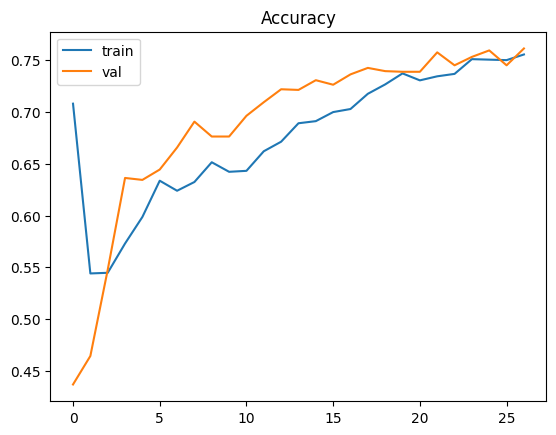

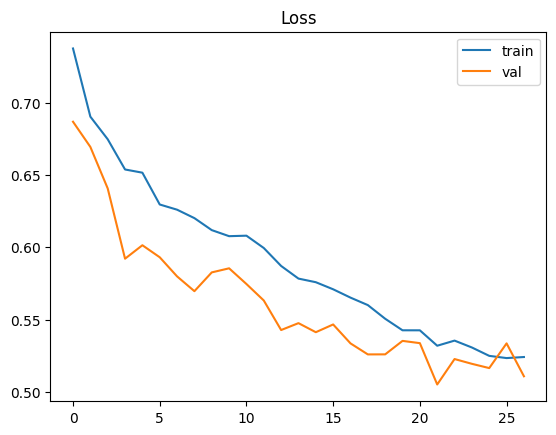

In [34]:
# plot the accuracy and loss

plt.plot(hist.history["accuracy"])
plt.plot(hist.history["val_accuracy"])
plt.title("Accuracy")
plt.legend(["train","val"])
plt.show()

plt.plot(hist.history["loss"])
plt.plot(hist.history["val_loss"])
plt.title("Loss")
plt.legend(["train","val"])
plt.show()

# Prediction

In [35]:
y_pred = model.predict(X_test_sc)

y_pred = (y_pred > 0.5)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step  


In [36]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.7545


# Confusion matrics

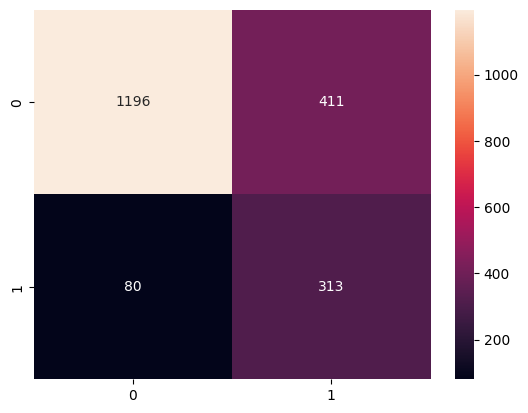

              precision    recall  f1-score   support

           0       0.94      0.74      0.83      1607
           1       0.43      0.80      0.56       393

    accuracy                           0.75      2000
   macro avg       0.68      0.77      0.70      2000
weighted avg       0.84      0.75      0.78      2000



In [37]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d")
plt.show()

print(classification_report(y_test, y_pred))

# Model and scaler

In [38]:
# import pickle

# # save model (new format)
# model.save("../output/churn_model.keras")

# # save scaler
# with open("../output/scaler.pkl", "wb") as f:
#     pickle.dump(sc, f)

# print("Model and scaler saved")